In [1]:
# Comment the following lines if you're not in colab:
from google.colab import drive
drive.mount('/content/drive')
# If you're in colab, cd to your own working directory here:
%cd ..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4

Mounted at /content/drive
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-4


# <u>MelGAN's Generator</u>
### (MelGAN: Generative Adversarial Networks for Conditional Waveform Synthesis, Kumar et al., 2019) ###
https://arxiv.org/pdf/1910.06711.pdf  
https://github.com/descriptinc/melgan-neurips

The problem addressed by this model is **Text-To-Speech (TTS)** synthesis. This task can be solved either with an **end-to-end (E2E)** model or by decomposing it into two stages:

![](fig/topic.png)
![](https://drive.google.com/uc?export=view&id=1c-AHn6Ihcu5jxvDn1W9oUx1yJkgRe9xz)

In this notebook we will focus on the **second stage**, namely the transformation from **speech features to speech waveforms**. The component performing this task is called a **vocoder**, and it can be implemented as a neural network model (generative or not).

In our case, the speech features will be **Mel-spectrograms**. We will not cover them in detail here since they fall outside the scope of this tutorial. Roughly speaking, Mel-spectrograms are a compressed representation of traditional (linear) spectrograms. Even if you are not familiar with spectrograms, you can think of them as a **time–frequency representation of audio**, where the x-axis represents **time** and the y-axis represents **frequency**.

As its name suggests, MelGAN is a **Generative Adversarial Network (GAN)**. However, since GANs have not been introduced yet in this course, we will only study **MelGAN's generator**, the CNN responsible for converting Mel-spectrograms into speech waveforms.

MelGAN has become a very influential model because it achieves an excellent trade-off between **computational cost, audio quality, and inference speed**, which is why it has also found practical use in industry.

In [2]:
!pip install torchinfo

In [3]:
from librosa.filters import mel as librosa_mel_fn  # pip install librosa
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import librosa
import random
import os

import torch as tc
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import DataLoader

device = tc.device("cuda" if tc.cuda.is_available() else "cpu")

### <u>DSP Hyperparameters & Mel-Spectrogram</u>

+ **fs** = Sampling frequency in Hz.
+ **seq_len** = Length (in samples) of the audio sequences used to train the network. These sequences are converted into **Mel-spectrograms** before being fed into the generator.
+ **no_mels** = Number of Mel frequency bins in the Mel-spectrogram. This corresponds to the length of the **y-axis** of the Mel-spectrogram.
+ **win_length** = Length (in samples) of the **Hanning window** used to compute the Mel-spectrogram.
+ **hop_length** = Number of samples by which the window is shifted each time. Each hop produces one Mel-spectrum of length **no_mels**. Therefore, `seq_len // hop_length` is the number of hops that fit inside `seq_len`.
+ **input_shape** = Shape of the input fed to the network. This is a **2D representation** where the y-axis has length **no_mels** and the x-axis has length `seq_len // hop_length`.

In [4]:
fs = 22050
seq_len = 8192  # (~0.37 seconds)
no_fft = 1024
win_length = 1024
hop_length = 256
no_mels = 80
input_shape = (no_mels, seq_len//hop_length)

When MelGAN was introduced, the class `torchaudio.transforms.MelSpectrogram` did not yet exist, so Mel-spectrogram extraction was often implemented manually.

In this notebook, we will also implement our own PyTorch-based Mel-spectrogram module. This is mainly done for **instructional purposes**, and it also provides **greater control and flexibility** over the signal processing pipeline.

When implementing such components manually, it is important to ensure that the operations we use are **compatible with PyTorch's computational graph**, i.e., they should remain **differentiable** if gradients need to flow through them during training:

In [5]:
class Audio2Mel(nn.Module):
    def __init__(
        self,
        n_fft=no_fft,
        hop_len=hop_length,
        win_len=win_length,
        sr=fs,
        n_mel_channels=no_mels,
        mel_fmin=0.0,
        mel_fmax=fs/2,
    ):
        super().__init__()
        ##############################################
        # FFT Parameters                             #
        ##############################################
        window = tc.hann_window(win_len).float()
        mel_basis = librosa_mel_fn(
            sr=sr,
            n_fft=n_fft,
            n_mels=n_mel_channels,
            fmin=mel_fmin,
            fmax=mel_fmax
        )
        mel_basis = tc.from_numpy(mel_basis).float()

        self.register_buffer("mel_basis", mel_basis)
        self.register_buffer("window", window)
        self.n_fft = n_fft
        self.hop_length = hop_len
        self.win_length = win_len
        self.sampling_rate = sr
        self.n_mel_channels = n_mel_channels

    def forward(self, audio):
        p = (self.n_fft - self.hop_length) // 2
        audio = F.pad(audio, (p, p), "reflect").squeeze(1)
        stft = tc.stft(
            input=audio,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=self.window,
            center=False,
            return_complex=True
        )
        magnitude = tc.sqrt(stft.real ** 2 + stft.imag ** 2)
        mel_output = tc.matmul(self.mel_basis, magnitude)
        log_mel_spec = tc.log10(tc.clamp(mel_output, min=1e-5))
        return log_mel_spec

Load a speech file:

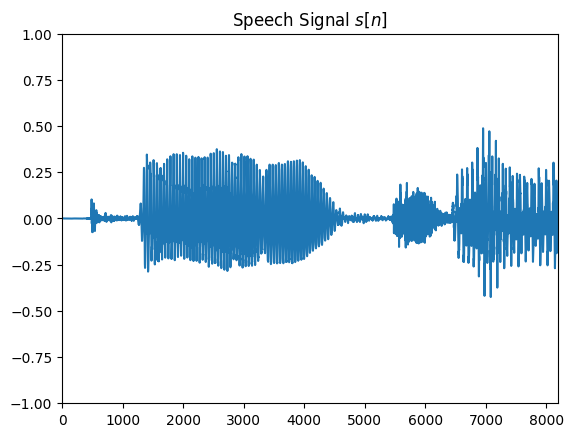

In [6]:
wav_path = os.path.join('data', 'wav')

test_sigs = np.zeros(shape=(16, seq_len))
test_sig, sampling_rate = librosa.core.load(
    os.path.join(wav_path, "LJ001-0001.wav"), sr=fs
)
test_sigs[0] = test_sig[:seq_len]

plt.figure()
plt.plot(test_sigs[0])
plt.xlim([0, seq_len])
plt.ylim([-1, 1])
plt.title("Speech Signal $s[n]$")
plt.show()
plt.close()

Plot the corresponding Mel-Spectrogram and input-output shapes to see that it is working as intended:

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_468/2244871381.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Log Mel-Spec $\mathbf{S}[k, m]$")


Input shape (time domain) = torch.Size([16, 8192])
Output shape (mel domain) = torch.Size([16, 80, 32])


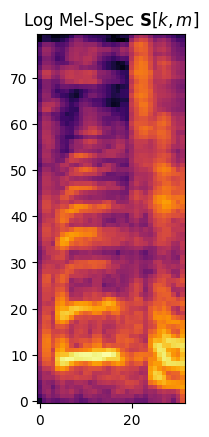

In [7]:
test_sigs = tc.from_numpy(test_sigs).to(device=device, dtype=tc.float32)

mel = Audio2Mel().to(device)
print(f"Input shape (time domain) = {test_sigs.shape}")
melspecs = mel(test_sigs)
print(f"Output shape (mel domain) = {melspecs.shape}")

plt.figure()
plt.plot()
plt.imshow(melspecs[0].cpu(), cmap="inferno")
ax = plt.gca()
ax.set_ylim(ax.get_ylim()[::-1])
plt.title("Log Mel-Spec $\mathbf{S}[k, m]$")
plt.show()
plt.close()

### <u>Weight Distribution Initialization</u>

The choice of distribution for **weight initialization** is often overlooked, but it can significantly influence the **convergence speed** of a network and help mitigate gradient-related issues that arise from poorly chosen initial weights.

Proper initialization can also lead to a more balanced distribution of **activations across layers**, allowing the network to learn useful patterns more efficiently.

For further reading:  
https://wandb.ai/wandb_fc/tips/reports/How-to-Initialize-Weights-in-PyTorch--VmlldzoxNjcwOTg1

In this case, it turns out that using a **normal distribution** performs better than the default initialization (which is typically **uniform** in many PyTorch layers):

In [8]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        m.weight.data.normal_(mean=0.0, std=0.02)

### <u>Weight Normalization (Salimans & Kingma, 2016)</u>

https://arxiv.org/pdf/1602.07868.pdf  

The term *normalization* can be somewhat misleading here. In this context, we do not normalize the weights in the traditional sense (e.g., forcing them to have unit norm or specific statistical properties). Instead, the technique is better understood as a **reparameterization** of the weights.

Weight normalization improves neural network training by **decoupling the magnitude of the weight vector from its direction**. This is achieved by expressing a weight vector $\mathbf{w}$ in terms of a direction vector $\mathbf{v}$ and a scalar parameter $g$:

\begin{equation}
\mathbf{w} = g \dfrac{\mathbf{v}}{\|\mathbf{v}\|},
\end{equation}

where $\|\mathbf{v}\|$ denotes the **Euclidean norm** of $\mathbf{v}$. The vector $\mathbf{v} / \|\mathbf{v}\|$ represents the **unit direction** of the weight vector, while the scalar parameter $g$ controls its magnitude.

In practice, this reparameterization is applied **per weight vector** (e.g., per output neuron in a linear layer or per output channel in a convolutional layer), meaning that each vector (row) has its own scale parameter $g$.

It is therefore reasonable to think of weight normalization as a factorization of the form  
$w = (\text{scale}) \cdot (\text{direction})$.

Note that this parameterization introduces an additional learnable parameter, namely the scalar $g$. The goal of this approach is to **improve the conditioning of the optimization problem**, which often leads to **faster convergence** when training with stochastic gradient descent.

The following example illustrates how the magnitude and direction of the weight vector become decoupled:

> **Note:** In this example we compute $v = \dfrac{w}{\|w\|}$, so $v$ is unit-norm. During training, however, $v$ is a free parameter and will generally **not** have unit norm. The normalization $\dfrac{v}{\|v\|}$ ensures that the direction remains unit length while $g$ controls the magnitude.

In [28]:
# Assume we have these weights (2 output neurons, 3 inputs):
w = np.asarray([[0.6, -0.4, 0.2],
                [0.1, 0.03, -0.1]])
print(f"w =\n{w}, \n(old trainable parameters)\n")

# Compute one g per row:
g = np.linalg.norm(w, axis=1, keepdims=True)
print(f"g =\n{g}, \n(new trainable scale parameters)\n")

# Direction vectors:
v = w / g
print(f"v =\n{v}, \n(new trainable direction parameters)\n")

# Check that ||v|| = 1 per row:
v_norm = np.linalg.norm(v, axis=1)
print(f"||v|| = {v_norm}, \n(vectors are unit-norm per row)\n")

# Recover the original weights:
w_reconstructed = g * v
print(f"g * v =\n{w_reconstructed}, \n(reconstructed old trainable parameters)")

w =
[[ 0.6  -0.4   0.2 ]
 [ 0.1   0.03 -0.1 ]], 
(old trainable parameters)

g =
[[0.74833148]
 [0.14456832]], 
(new trainable scale parameters)

v =
[[ 0.80178373 -0.53452248  0.26726124]
 [ 0.69171446  0.20751434 -0.69171446]], 
(new trainable direction parameters)

||v|| = [1. 1.], 
(vectors are unit-norm per row)

g * v =
[[ 0.6  -0.4   0.2 ]
 [ 0.1   0.03 -0.1 ]], 
(reconstructed old trainable parameters)


Weight normalization will be applied to all layers of the network. A clean way to ensure this is to define our own layer wrappers where weight normalization is included by default:

In [10]:
def wn_conv1d(*args, **kwargs):
    return nn.utils.parametrizations.weight_norm(nn.Conv1d(*args, **kwargs))

def wn_convtranspose1d(*args, **kwargs):
    return nn.utils.parametrizations.weight_norm(nn.ConvTranspose1d(*args, **kwargs))

### <u>Residual and Skip Connections</u>

The following diagram illustrates a **residual connection** used in MelGAN (note that the input is added to the output):

<img src="fig/res_stack.png" width="450">

<img src="https://drive.google.com/uc?export=view&id=13WJajT_DnzGeYyQIMrpx8eOOOaKagNsv" width="450">

**Skip connections** and **residual connections** are closely related architectural concepts and are sometimes used interchangeably.  

Skip connections (popularized by the ResNet architecture) refer more generally to any mechanism that allows information to **bypass one or more layers** in a network.

Residual connections are a **specific type of skip connection**, where the input of a layer (or group of layers) is **added to its output**, effectively skipping the intermediate layers (as shown in the figure above). The intermediate layers therefore learn a **residual function** relative to the input.

Some benefits of skip/residual connections include:

+ **Alleviating vanishing gradient issues:** Gradients can flow directly through the skip path, helping preserve their magnitude and enabling the training of deeper networks.
+ **Reducing information loss:** Intermediate layers may discard useful information during training; skip connections help preserve important signals.
+ **Simplifying optimization:** Learning a residual mapping relative to the input is often easier than learning the full transformation from scratch.

In [11]:
# Leaky ReLU (negative) slope:
a = 0.2

In [12]:
class ResnetBlock(nn.Module):
    def __init__(self, dim, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LeakyReLU(a),
            nn.ReflectionPad1d(padding=dilation),
            wn_conv1d(
                in_channels=dim,
                out_channels=dim,
                kernel_size=3,
                dilation=dilation
            ),
            nn.LeakyReLU(a),
            wn_conv1d(
                in_channels=dim,
                out_channels=dim,
                kernel_size=1
            ),
        )

        self.shortcut = wn_conv1d(
            in_channels=dim,
            out_channels=dim,
            kernel_size=1
        )

    # The input goes through a 1×1 shortcut conv
    # and is added to the two-conv block output:
    def forward(self, x):
        return self.shortcut(x) + self.block(x)

The class above will be used to create multiple residual blocks, which together form a **residual stack**. This stack is the main component of the generator: it progressively refines the intermediate representations and drives the **Mel-to-waveform** transformation. This is the previous image unfolded, which shows the convolutional **stack**:

<img src="fig/res_stack_exp.png" width="550"/>

<img src="https://drive.google.com/uc?export=view&id=1km2DYaa3IP1o2BjEtPdbtd7HCCIEo41C" width="550"/>

## <u>Generator Architecture</u>
Goal: Create a fully convolutional architecture to learn the transformation $\mathcal{T}\{\mathbf{S}[k]\} = s[n]$, where $\mathbf{S}$ is a Mel-spectrogram and $s$ is its corresponding speech waveform.  

Note: This is a **one-to-many** problem. For example, spectrogram-based representations do not explicitly contain phase information, so multiple waveforms can correspond to the same magnitude representation.

Also, unlike the tasks we have seen so far (e.g., handwritten digit classification), this is a **regression** task: we are given as input a (2D) time series and we want to generate another (1D) time series. Since the output is high-dimensional, regression problems of this kind are typically more challenging than standard classification problems.


#### <u>Dimension Analysis</u>

Analysing how the dimensions change during the forward pass is an important part of designing a neural network architecture.  

Here, the input is an $80 \times 32$ matrix, which corresponds (in our setup) to a waveform segment of length $8192$, i.e., a $1 \times 8192$ vector. Therefore, we want to progressively **downsample the y-axis** (frequency) and **upsample the x-axis** (time).

To handle these dimension changes, we will mainly use **transposed convolutional layers** (explained in the PDF of the second tutorial). In our implementation, the y-axis (frequency bins) is treated as the **channel dimension**, so the number of channels will evolve roughly as follows:

$80$ channels (input) → conv #1 → $512$ channels → tr conv #1 → $256$ channels → tr conv #2 → $128$ channels → $\cdots$ → $1$ channel (output)

For the x-axis (time), upsampling in transposed convolutions is controlled by the stride, and the overall upsampling factor becomes **multiplicative** across layers. Therefore, we must choose strides whose product maps the input length $32$ to the output length $8192$. MelGAN uses the factors $8, 8, 2, 2$, since: $32 \cdot 8 \cdot 8 \cdot 2 \cdot 2 = 8192$

Putting everything together, the overall spatial transformation is:

$80 \times 32$ → conv #1 → $512 \times 32$ → tr conv #1 → $256 \times 256$ → tr conv #2 → $128 \times 2048$ → tr conv #3 → $64 \times 4096$ → tr conv #4 → $32 \times 8192$ → last conv → $1 \times 8192$

Lastly, **inserting residual stacks** between these layers completes our architecture. The figure below summarizes the full model:

<img src="fig/gen.png" width="650">

<img src="https://drive.google.com/uc?export=view&id=1yZFIAyQZy0nm0ry5_kTH5rOQRc_hqT0a" width="650">

To implement the above architecture we have the following code:

In [13]:
class Generator(nn.Module):
    def __init__(self, input_size, n_residual_layers):
        super().__init__()

        no_channels = [512, 256, 128, 64, 32]
        ratios = [8, 8, 2, 2]
        self.hop_length = np.prod(ratios)

        # First layer increases the dimensionality from 80 --> 512 channels:
        model = [
            wn_conv1d(
                in_channels=input_size,
                out_channels=no_channels[0],
                kernel_size=7,
                padding='same'
            ),
        ]

        # Then follows a series of:
        for i, r in enumerate(ratios):
            # Transposed convolution to upsample x-axis and downsample y-axis:
            model += [
                nn.LeakyReLU(a),
                wn_convtranspose1d(
                    in_channels=no_channels[i],
                    out_channels=no_channels[i + 1],
                    kernel_size=r * 2,
                    stride=r,
                    padding=r // 2 + r % 2,
                    output_padding=r % 2,
                ),
            ]
            # Residual stack to progress with the transformation:
            for j in range(n_residual_layers):
                model += [
                    ResnetBlock(
                        dim=no_channels[i+1],
                        dilation=3 ** j
                    )
                ]

        # Final layer outputs the desired dimensionality 32 --> 1 channels:
        model += [
            nn.LeakyReLU(a),
            nn.ReflectionPad1d(padding=3),
            wn_conv1d(
                in_channels=no_channels[-1],
                out_channels=1,
                kernel_size=7,
                padding=0
            ),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*model)
        self.apply(weights_init)

    def forward(self, x):
        return self.model(x)

### <u>Inference:</u>

One advantage of using a fully convolutional network for this task is that we can feed Mel-spectrograms of **arbitrary time length** (although not an arbitrary number of Mel bins). This is because convolutional filters do not depend on the absolute length of the sequence they slide over; they apply the same local operation at every time step.

Let's create an instance of the model and verify that the forward pass works for different input lengths:

In [14]:
batch_size = 4  # normally set to 16 for this model
n_res_layers = 3
netG = Generator(input_size=80, n_residual_layers=3).to(device=device)

print(f"Audio seq_len = {seq_len} samples long for training:")
print(f"Input shape  (time domain) = {test_sigs.shape}")
melspecs = mel(test_sigs)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

print(f"\nAudio fs = {fs} samples long for inference:")
test_sig2 = tc.from_numpy(test_sig[:fs]).view(1, fs).to(device)
print(f"Input shape  (time domain) = {test_sig2.shape}")
melspecs = mel(test_sig2)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

print(f"\nAudio 2*fs = {2*fs} samples long for inference:")
test_sig3 = tc.from_numpy(test_sig[:2*fs]).view(1, 2*fs).to(device=device)
print(f"Input shape  (time domain) = {test_sig3.shape}")
melspecs = mel(test_sig3)
print(f"Input shape  (mel domain)  = {melspecs.shape}")
out = netG(melspecs)
print(f"Output shape (time domain) = {out.shape}")

Audio seq_len = 8192 samples long for training:
Input shape  (time domain) = torch.Size([16, 8192])
Input shape  (mel domain)  = torch.Size([16, 80, 32])
Output shape (time domain) = torch.Size([16, 1, 8192])

Audio fs = 22050 samples long for inference:
Input shape  (time domain) = torch.Size([1, 22050])
Input shape  (mel domain)  = torch.Size([1, 80, 86])
Output shape (time domain) = torch.Size([1, 1, 22016])

Audio 2*fs = 44100 samples long for inference:
Input shape  (time domain) = torch.Size([1, 44100])
Input shape  (mel domain)  = torch.Size([1, 80, 172])
Output shape (time domain) = torch.Size([1, 1, 44032])


Printing the summary for the MelGAN Generator:

In [15]:
print(summary(
    model=netG,
    input_size=(batch_size, *input_shape),
    device=device
))

Layer (type:depth-idx)                                       Output Shape              Param #
Generator                                                    [4, 1, 8192]              --
├─Sequential: 1-1                                            [4, 1, 8192]              --
│    └─ParametrizedConv1d: 2-1                               [4, 512, 32]              512
│    │    └─ModuleDict: 3-1                                  --                        287,232
│    └─LeakyReLU: 2-2                                        [4, 512, 32]              --
│    └─ParametrizedConvTranspose1d: 2-3                      [4, 256, 256]             256
│    │    └─ModuleDict: 3-2                                  --                        2,097,664
│    └─ResnetBlock: 2-4                                      [4, 256, 256]             --
│    │    └─ParametrizedConv1d: 3-3                          [4, 256, 256]             66,048
│    │    └─Sequential: 3-4                                  [4, 256, 256]   

## <u>Dataset Handling</u>

We assume we have access to a sufficiently large collection of `.wav` audio files for training, such as the LJ-Speech dataset:  
https://keithito.com/LJ-Speech-Dataset/

There are two common ways to handle Mel-spectrograms:

- **Precompute and save them** before training (faster training, but requires extra disk space), or
- **Compute them on-the-fly** during training (no extra storage, but adds computation per step)

In this notebook we follow the second approach, as in the original MelGAN repository.

The overall procedure is:

1. Create two files (e.g., `.txt`) containing the filenames for the training and test sets, given a split (e.g., $90$--$10$).
2. For each training audio file:
   2.1 Sample a **random** segment of length `seq_len` (in samples).  
   2.2 Convert the segment into a **Mel-spectrogram**.  
   2.3 Use it to train the model (forward pass, loss, backpropagation, optimizer step).  
3. Once all files have been processed, an epoch has elapsed. Repeat step 2 until the stopping criterion is met.

In practice, the above is performed on **batches** (`batch_size`) rather than one file at a time. PyTorch’s `DataLoader` handles batching automatically; we only need to define what happens for a single file inside the dataset class.

Since we sample random segments from each file, each epoch is effectively **different**, i.e., the model sees different chunks of audio across epochs. This is a common strategy in waveform generation tasks, as it reduces overfitting and tends to improve generalization.

The following cell implements step (1) of the procedure:

In [16]:
def create_dataset(path, train_percent):
    """
    Creates the train_files.txt and test_files.txt files, given a folder of ONLY .wav files (path)
    and what percentage in (0,1) of the .wav files to use for training (train_percent), a.k.a. split.
    The rest (1-train_percent) will be used for testing.
    """
    all_files = [file for file in os.listdir(path)]

    no_all_files = len(all_files)
    no_train_files = int(train_percent*no_all_files)

    train_files = all_files[0:no_train_files]
    test_files = all_files[no_train_files:no_all_files]

    with open(os.path.join(path, 'train_files.txt'), 'w') as f:
        f.write('\n'.join(train_files))
    with open(os.path.join(path, 'test_files.txt'), 'w') as f:
        f.write('\n'.join(test_files))

    return

Which can be used like so to train with e.g., $80$% of the audio files we have:

In [17]:
create_dataset(path=wav_path, train_percent=.8)

Now it is time for the custom dataset class, done by extending ``toch.utils.data.Dataset``. The `__init__`, `__getitem__`, and `__len__` methods need to be implemented:

In [18]:
def files_to_list(filename):
    """
    Takes a text file of filenames and makes a list of filenames.
    """
    with open(filename, encoding="utf-8") as f:
        files = f.readlines()
    return [f.rstrip() for f in files]

class AudioDataset(tc.utils.data.Dataset):
    """
    The main class for creating MelGAN's dataset.
    """
    def __init__(self, files, segment_length, sr, augment=True):
        self.sampling_rate = sr
        self.segment_length = segment_length
        self.audio_files = files_to_list(files)
        self.audio_files = [pathlib.Path(files).parent / x for x in self.audio_files]
        random.seed(1234)
        random.shuffle(self.audio_files)
        self.augment = augment

    def __getitem__(self, index):
        # Read the audio :
        filename = self.audio_files[index]
        audio, sr = self.load_wav_to_torch(filename)
        # Take a random segment :
        if audio.size(0) >= self.segment_length:
            max_audio_start = audio.size(0) - self.segment_length
            audio_start = random.randint(0, max_audio_start)
            audio = audio[audio_start: audio_start + self.segment_length]
        else:
            audio = F.pad(
                input=audio,
                pad=(0, self.segment_length - audio.size(0)),
                mode="constant",
                value=0.0
            ).data
        return audio.unsqueeze(0)

    def __len__(self):
        return len(self.audio_files)

    def load_wav_to_torch(self, full_path):
        """
        Helper method to load wav data into torch array.
        """
        data, sr = librosa.core.load(full_path, sr=self.sampling_rate)
        data = 0.95 * librosa.util.normalize(data)
        if self.augment:
            data *= np.random.uniform(low=0.3, high=1.0)
        return tc.from_numpy(data).float(), sr

And now we can create our dataloaders like so:

In [19]:
# Train and test datasets:
train_set = AudioDataset(
    files=pathlib.Path(wav_path)/"train_files.txt",
    segment_length=seq_len,
    sr=fs,
    augment=True
)
test_set = AudioDataset(
    files=pathlib.Path(wav_path)/"test_files.txt",
    segment_length=fs*4,
    sr=fs,
    augment=False
)

# Train and test data loaders:
train_loader = DataLoader(
    dataset=train_set,
    batch_size=batch_size
    # num_workers=1  # normally e.g., 4 for faster parallel loads
)
test_loader = DataLoader(
    dataset=test_set,
    batch_size=1
)

### <u>Training Loop Sketch </u> ###
With everything now put together thus far, this is how our main training loop would look like:

In [20]:
no_epochs = 5

for epoch in range(1, no_epochs+1):

    print(f"Epoch {epoch}/{no_epochs}")

    for iterno, sigs in enumerate(train_loader):

        print(f" Iteration {iterno+1}/{len(train_loader)}")

        # Put batch of signals to device:
        sigs = sigs.to(device=device)

        # Convert them to Log Mel-Spectrograms:
        # detach() just removes the tensor from the computational graph
        # as to not track gradients through the Mel computation
        specs = mel(sigs).detach().to(device=device)

        # Call the generator network:
        sigs_hat = netG(specs)

        # call discriminator
        # ...

        # measure losses
        # ...

        # backpropagate errors
        # ...

        # save best model
        # ...

        # save samples
        # ...

        # etc.

Epoch 1/5
 Iteration 1/2
 Iteration 2/2
Epoch 2/5
 Iteration 1/2
 Iteration 2/2
Epoch 3/5
 Iteration 1/2
 Iteration 2/2
Epoch 4/5
 Iteration 1/2
 Iteration 2/2
Epoch 5/5
 Iteration 1/2
 Iteration 2/2


The two biggest parts we are still missing are:

1. **The discriminator network:** this requires an introduction to GANs in order to make sense of its role.
2. **A loss function:** in GANs, the loss is tightly connected with the discriminator as well. However, we can still train the generator with a loss of our own, e.g., a spectral-distance criterion between the ground-truth and generated waveforms.

We will revisit both in an upcoming tutorial. Some additional things to think about:

1. **How can we make this model (with the generator alone) "more" generative?**  
   One idea is to add a noise channel as **conditioning**. For starters, we could change the input channels of the first layer from $80$ to $81$, and append a channel of (for example) Gaussian noise to the Mel-spectrogram before feeding it to the network.
2. **If we train this model using speech from a single speaker, the model will learn that speaker's voice. Can we make it multi-speaker?**  
   One idea is to add speaker-specific conditioning as extra input channel(s), such as the speaker’s **fundamental frequency** (F0).